In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
merged_df = pd.read_csv("C:/Users/Dell/Downloads/final_poverty_wdi_engineered.csv")

# Convert date if present
if "date" in merged_df.columns:
    merged_df["date"] = pd.to_datetime(merged_df["date"], errors="coerce")

# Style settings
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Dataset shape:", merged_df.shape)
merged_df.head()

C:\Users\Dell\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Dataset shape: (355, 38)


,country_code,year,mean_avg_welfare,median_quantile,welfare_std,welfare_iqr,total_pop,is_partial_year,bottom20_avg_welfare,bottom20_welfare_share,...,log_gdp_per_capita,date,decade,inequality_category,gdp_per_capita_norm,life_expectancy_norm,school_enrollment_secondary_norm,electricity_access_norm,development_score,development_tier
0,ALB,2019,14.631818,12.356349,8.727751,9.127375,28472.751151,False,6.225324,0.085093,...,8.711186,2019-01-01,2010,Low inequality,0.043156,0.884985,0.576078,1.0,0.626055,Medium development
1,ALB,2020,14.847158,12.838601,8.448225,9.211061,28031.916239,False,6.267664,0.084429,...,8.704322,2020-01-01,2020,Low inequality,0.042848,0.847881,0.553376,1.0,0.611026,Medium development
2,ARM,2019,9.087722,7.717232,6.495384,4.861010,28849.577912,False,4.060171,0.089355,...,8.433426,2019-01-01,2010,Low inequality,0.032228,0.811701,0.486401,1.0,0.582583,Low development
3,ARM,2020,8.589780,7.608539,4.513978,4.245442,27146.378537,False,4.392951,0.102283,...,8.359294,2020-01-01,2020,Low inequality,0.029789,0.747422,0.498776,1.0,0.568997,Low development
4,ARM,2021,8.941558,7.749302,5.566521,4.569458,26523.512035,False,4.210894,0.094187,...,8.452373,2021-01-01,2020,Low inequality,0.032881,0.722636,0.520681,1.0,0.569049,Low development


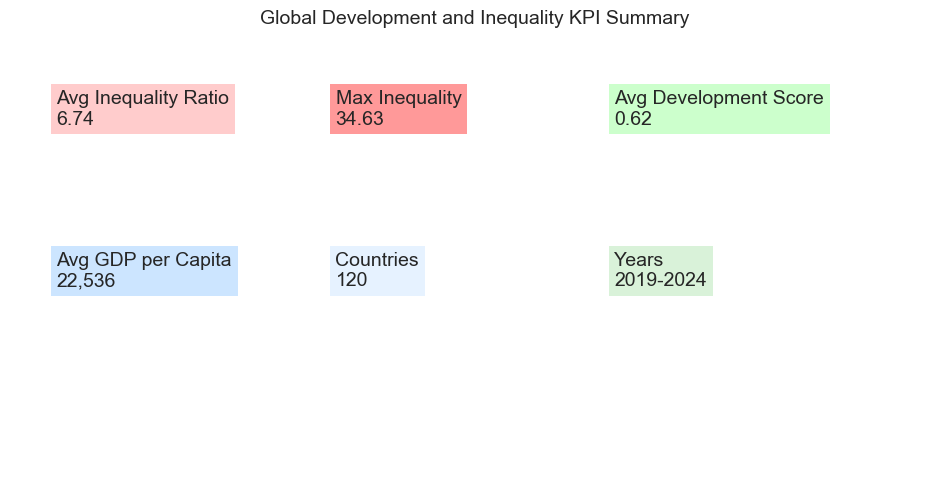

In [2]:
avg_inequality = merged_df["top20_bottom20_ratio"].mean()
max_inequality = merged_df["top20_bottom20_ratio"].max()
avg_dev_score = merged_df["development_score"].mean()
avg_gdp = merged_df["gdp_per_capita"].mean()
country_count = merged_df["country_name"].nunique()
year_min = int(merged_df["year"].min())
year_max = int(merged_df["year"].max())

fig, ax = plt.subplots(figsize=(12,6))
ax.axis("off")

ax.text(0.05,0.8,f"Avg Inequality Ratio\n{avg_inequality:.2f}",
        fontsize=14,bbox=dict(facecolor="#ffcccc",edgecolor="none"))

ax.text(0.35,0.8,f"Max Inequality\n{max_inequality:.2f}",
        fontsize=14,bbox=dict(facecolor="#ff9999",edgecolor="none"))

ax.text(0.65,0.8,f"Avg Development Score\n{avg_dev_score:.2f}",
        fontsize=14,bbox=dict(facecolor="#ccffcc",edgecolor="none"))

ax.text(0.05,0.45,f"Avg GDP per Capita\n{avg_gdp:,.0f}",
        fontsize=14,bbox=dict(facecolor="#cce5ff",edgecolor="none"))

ax.text(0.35,0.45,f"Countries\n{country_count}",
        fontsize=14,bbox=dict(facecolor="#e6f2ff",edgecolor="none"))

ax.text(0.65,0.45,f"Years\n{year_min}-{year_max}",
        fontsize=14,bbox=dict(facecolor="#d9f2d9",edgecolor="none"))

plt.title("Global Development and Inequality KPI Summary")
plt.show()

In [39]:
import plotly.express as px

# calculate yearly inequality
yearly_ineq = (
    merged_df.groupby("year")["top20_bottom20_ratio"]
    .mean()
    .reset_index()
)

# create interactive line chart
fig = px.line(
    yearly_ineq,
    x="year",
    y="top20_bottom20_ratio",
    markers=True,
    title="Average Inequality Ratio Over Time",
    labels={
        "year": "Year",
        "top20_bottom20_ratio": "Top20 / Bottom20 Income Ratio"
    }
)

# customize hover
fig.update_traces(
    hovertemplate=
    "<b>Year:</b> %{x}<br>" +
    "<b>Inequality Ratio:</b> %{y:.2f}<extra></extra>",
    line=dict(color="#d62728", width=3)
)

fig.show()

In [25]:
import plotly.express as px

# calculate top 10 inequality countries
top10_ineq = (
    merged_df.groupby("country_name")["top20_bottom20_ratio"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# interactive bar chart
fig = px.bar(
    top10_ineq,
    x="top20_bottom20_ratio",
    y="country_name",
    orientation="h",
    color="top20_bottom20_ratio",
    color_continuous_scale="Reds",
    title="Top 10 Countries with Highest Inequality",
    labels={
        "top20_bottom20_ratio": "Average Inequality Ratio",
        "country_name": "Country"
    }
)

# customize hover
fig.update_traces(
    hovertemplate=
    "<b>Country:</b> %{y}<br>" +
    "<b>Inequality Ratio:</b> %{x:.2f}<extra></extra>"
)

# show highest at top
fig.update_layout(yaxis=dict(autorange="reversed"))

fig.show()

In [23]:
import plotly.express as px

fig = px.scatter(
    merged_df,
    x="log_gdp_per_capita",
    y="top20_bottom20_ratio",
    hover_name="country_name",
    hover_data={
        "year": True,
        "gdp_per_capita": True,
        "top20_bottom20_ratio": ":.2f"
    },
    opacity=0.6,
    color_discrete_sequence=["#1f77b4"],
    title="GDP per Capita vs Income Inequality"
)

fig.update_layout(
    xaxis_title="Log GDP per Capita",
    yaxis_title="Top20 / Bottom20 Ratio"
)

fig.show()

In [27]:
import plotly.express as px

corr_cols = [
    "gdp_per_capita",
    "life_expectancy",
    "school_enrollment_secondary",
    "electricity_access",
    "unemployment_total",
    "top20_bottom20_ratio",
    "development_score"
]

corr_matrix = merged_df[corr_cols].corr()

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    title="Correlation Between Development Indicators"
)

# center color scale
fig.update_coloraxes(cmid=0)

# customize hover text
fig.update_traces(
    hovertemplate=
    "<b>Indicator 1:</b> %{x}<br>" +
    "<b>Indicator 2:</b> %{y}<br>" +
    "<b>Correlation:</b> %{z:.2f}<extra></extra>"
)

fig.show()

In [28]:
import plotly.express as px

fig = px.box(
    merged_df,
    x="development_tier",
    y="top20_bottom20_ratio",
    color="development_tier",
    hover_data={
        "country_name": True,
        "year": True,
        "top20_bottom20_ratio": ":.2f"
    },
    title="Inequality Distribution by Development Tier",
    labels={
        "development_tier": "Development Tier",
        "top20_bottom20_ratio": "Income Inequality Ratio"
    }
)

fig.update_traces(
    hovertemplate=
    "<b>Development Tier:</b> %{x}<br>" +
    "<b>Inequality Ratio:</b> %{y:.2f}<br>" +
    "<b>Country:</b> %{customdata[0]}<br>" +
    "<b>Year:</b> %{customdata[1]}<extra></extra>"
)

fig.show()

C:\Users\Dell\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [33]:
import plotly.express as px
import numpy as np

# calculate statistics
mean_val = merged_df["top20_bottom20_ratio"].mean()
median_val = merged_df["top20_bottom20_ratio"].median()

fig = px.histogram(
    merged_df,
    x="top20_bottom20_ratio",
    nbins=20,
    template="simple_white",
    color_discrete_sequence=["#4E79A7"],
    title="Distribution of Global Income Inequality"
)

# mean line
fig.add_vline(
    x=mean_val,
    line_dash="dash",
    line_color="red",
    annotation_text=f"Mean = {mean_val:.2f}",
    annotation_position="top right"
)

# median line
fig.add_vline(
    x=median_val,
    line_dash="dot",
    line_color="green",
    annotation_text=f"Median = {median_val:.2f}",
    annotation_position="top left"
)

# improve hover
fig.update_traces(
    hovertemplate=
    "<b>Inequality Ratio:</b> %{x}<br>" +
    "<b>Frequency:</b> %{y}<extra></extra>"
)

fig.update_layout(
    xaxis_title="Top 20% / Bottom 20% Income Ratio",
    yaxis_title="Number of Observations",
    bargap=0.05
)

fig.show()

In [35]:
import plotly.express as px

fig = px.scatter(
    merged_df,
    x="log_gdp_per_capita",
    y="top20_bottom20_ratio",
    size="population_total",
    color="development_score",
    color_continuous_scale="Viridis",
    opacity=0.6,
    hover_name="country_name",
    hover_data={
        "year": True,
        "gdp_per_capita": True,
        "population_total": ":,",
        "top20_bottom20_ratio": False   # remove duplicate
    },
    title="GDP vs Inequality (Bubble Size = Population)",
    labels={
        "log_gdp_per_capita": "Log GDP per Capita",
        "top20_bottom20_ratio": "Income Inequality Ratio"
    }
)

fig.update_layout(template="simple_white")

fig.update_traces(
    hovertemplate=
    "<b>Country:</b> %{hovertext}<br>" +
    "<b>Year:</b> %{customdata[0]}<br>" +
    "<b>GDP per Capita:</b> %{customdata[1]}<br>" +
    "<b>Population:</b> %{customdata[2]:,}<br>" +
    "<b>Inequality Ratio:</b> %{y:.2f}<extra></extra>"
)

fig.show()

In [10]:
anomalies = (
    merged_df[
        ["country_name","year",
         "top20_bottom20_ratio",
         "development_score",
         "gdp_per_capita"]
    ]
    .sort_values("top20_bottom20_ratio",ascending=False)
    .head(10)
)

print("Top 10 Highest Inequality Observations")
display(anomalies)

Top 10 Highest Inequality Observations


,country_name,year,top20_bottom20_ratio,development_score,gdp_per_capita
350,Kosovo,2020,34.634185,0.578539,4310.889638
351,Kosovo,2021,27.497751,0.584661,5270.432369
59,Colombia,2021,19.061821,0.595430,6222.621644
34,Brazil,2019,18.664318,0.619429,9029.833044
58,Colombia,2020,18.604425,0.601853,5339.687114
60,Colombia,2022,18.504478,0.615189,6680.445069
36,Brazil,2021,17.444354,0.605961,7972.536961
61,Colombia,2023,17.239082,0.619461,7000.836605
37,Brazil,2022,15.840781,0.618978,9281.332821
38,Brazil,2023,15.348729,0.624220,10377.589772


In [11]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [41]:
import pandas as pd

pd.DataFrame.iteritems = pd.DataFrame.items

In [42]:
import pandas as pd
import plotly.express as px

pd.DataFrame.iteritems = pd.DataFrame.items

cols = [
    "log_gdp_per_capita",
    "life_expectancy",
    "school_enrollment_secondary",
    "electricity_access",
    "development_score"
]

pair_df = merged_df[cols + ["development_tier", "country_name"]].dropna()

fig = px.scatter_matrix(
    pair_df,
    dimensions=cols,
    color="development_tier",
    hover_name="country_name",
    title="Relationships Between Development Indicators"
)

fig.update_traces(diagonal_visible=False)

fig.update_layout(template="simple_white")

fig.show()

C:\Users\Dell\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



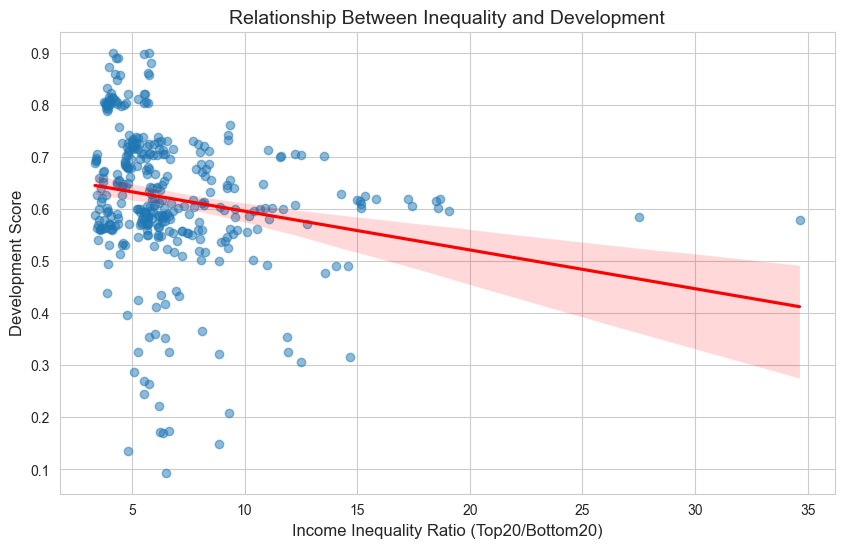

In [15]:
plt.figure()

sns.regplot(
    data=merged_df,
    x="top20_bottom20_ratio",
    y="development_score",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Relationship Between Inequality and Development")
plt.xlabel("Income Inequality Ratio (Top20/Bottom20)")
plt.ylabel("Development Score")

plt.show()

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a futu

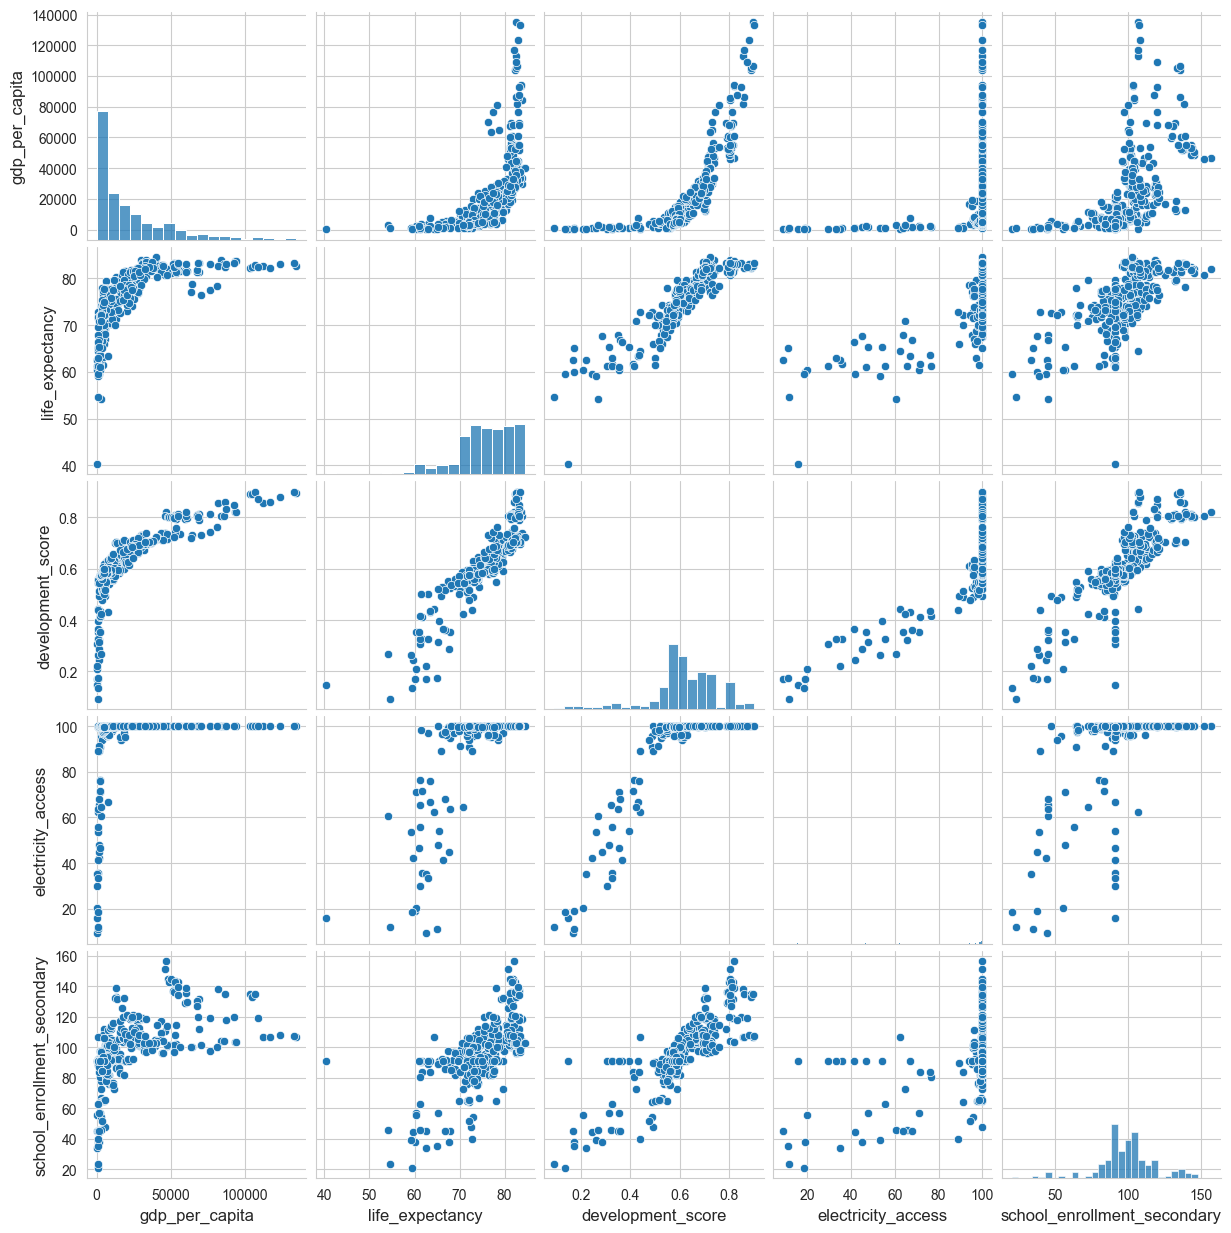

In [45]:
import seaborn as sns

cols = [
    "gdp_per_capita",
    "life_expectancy",
    "development_score",
    "electricity_access",
    "school_enrollment_secondary"
]

sns.pairplot(df[cols])

In [21]:
import plotly.express as px

# Aggregate inequality per country-year
map_data = (
    merged_df.groupby(["country_name", "year"], as_index=False)
    ["top20_bottom20_ratio"]
    .mean()
)

# Create animated choropleth map
fig = px.choropleth(
    map_data,
    locations="country_name",
    locationmode="country names",
    color="top20_bottom20_ratio",
    hover_name="country_name",
    hover_data={
        "top20_bottom20_ratio": True,
        "year": True
    },
    animation_frame="year",
    color_continuous_scale="Reds",
    labels={"top20_bottom20_ratio": "Inequality Ratio"},
    title="Global Income Inequality Over Time (Top 20% vs Bottom 20%)"
)

# Improve layout (professional look)
fig.update_layout(
    title_x=0.5,
    geo=dict(showframe=False, showcoastlines=True)
)

fig.show()

C:\Users\Dell\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [43]:
import plotly.graph_objects as go

yearly = merged_df.groupby("year").agg({
    "gdp_per_capita":"mean",
    "top20_bottom20_ratio":"mean"
}).reset_index()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=yearly["year"],
        y=yearly["gdp_per_capita"],
        name="GDP per Capita",
        mode="lines+markers",
        yaxis="y1"
    )
)

fig.add_trace(
    go.Scatter(
        x=yearly["year"],
        y=yearly["top20_bottom20_ratio"],
        name="Income Inequality",
        mode="lines+markers",
        yaxis="y2"
    )
)

fig.update_layout(
    title="Economic Growth vs Income Inequality Over Time",
    xaxis_title="Year",
    yaxis=dict(title="GDP per Capita"),
    yaxis2=dict(
        title="Top20 / Bottom20 Ratio",
        overlaying="y",
        side="right"
    ),
    template="simple_white"
)

fig.show()